# Airbnb Milano – Pulizia & EDA
**Dataset**: `listings_milan.csv` – snapshot giugno 2025  


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')



In [2]:
import os
os.makedirs('Output/plots', exist_ok=True)

In [4]:

# stile uniforme per tutto il notebook
sns.set_theme(style='whitegrid', palette='Blues_d')
plt.rcParams.update({'figure.dpi': 130, 'figure.figsize': (10, 4),
                     'axes.spines.top': False, 'axes.spines.right': False})

df_raw = pd.read_csv('Data\listings_milan.csv')
print(f'Shape originale: {df_raw.shape}')
df_raw.head(3)

Shape originale: (22948, 18)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,23986,""" Characteristic Milanese flat""",95941,Jeremy,NaN,NAVIGLI,45.44806,9.17373,Entire home/apt,180.0,31,26,2024-04-20,0.16,1,362,0,NaN
1,40470,Giacinto Cosy & clean flat near MM1,174203,Giacinto,NaN,VIALE MONZA,45.52023,9.22747,Entire home/apt,NaN,3,44,2025-07-31,0.24,2,357,1,IT015146C2YDCLSU8G
2,46536,Nico & Cinzia's Pink Suite!,138683,Nico&Cinzia,NaN,VIALE MONZA,45.52276,9.22478,Entire home/apt,86.0,3,39,2025-04-20,0.23,1,111,2,IT015209C2BBKGCMT7


---
## 1. Ispezione iniziale

In [5]:

print(df_raw.dtypes)
print()
print('=== VALORI MANCANTI ===')
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(1)
pd.DataFrame({'missing': missing, '%': missing_pct})[missing > 0]

id                                  int64
name                                  str
host_id                             int64
host_name                             str
neighbourhood_group               float64
neighbourhood                         str
latitude                          float64
longitude                         float64
room_type                             str
price                             float64
minimum_nights                      int64
number_of_reviews                   int64
last_review                           str
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
number_of_reviews_ltm               int64
license                               str
dtype: object

=== VALORI MANCANTI ===


,missing,%
host_name,18,0.1
neighbourhood_group,22948,100.0
price,2395,10.4
last_review,3426,14.9
reviews_per_month,3426,14.9
license,3201,13.9


In [8]:
print(df_raw[['reviews_per_month', 'last_review']].head(3))

   reviews_per_month last_review
0               0.16  2024-04-20
1               0.24  2025-07-31
2               0.23  2025-04-20


In [9]:
# Filtra il dataframe dove 'reviews_per_month' è NaN
df_nulle = df_raw[df_raw['reviews_per_month'].isna()]

# Seleziona solo le due colonne che ti interessano e mostra la tabella
display(df_nulle[['reviews_per_month', 'last_review']])
df_nulle.isna().sum()

,reviews_per_month,last_review
23,NaN,NaN
76,NaN,NaN
136,NaN,NaN
159,NaN,NaN
168,NaN,NaN
...,...,...
22943,NaN,NaN
22944,NaN,NaN
22945,NaN,NaN
22946,NaN,NaN


id                                   0
name                                 0
host_id                              0
host_name                            4
neighbourhood_group               3426
neighbourhood                        0
latitude                             0
longitude                            0
room_type                            0
price                              530
minimum_nights                       0
number_of_reviews                    0
last_review                       3426
reviews_per_month                 3426
calculated_host_listings_count       0
availability_365                     0
number_of_reviews_ltm                0
license                           1389
dtype: int64

da qui possiamo vedere che tutti i valori nan in reviews_per_month hanno anche i Nan last_reviews--> quindi semplicemente non ci sono state reviews e filliamo con 0

In [50]:
print('=== STATISTICHE DESCRITTIVE (colonne numeriche) ===')
df_raw.describe().T

=== STATISTICHE DESCRITTIVE (colonne numeriche) ===


,count,mean,std,min,25%,50%,75%,max
id,22948.0,8.345252e+17,5.441363e+17,23986.00000,5.292885e+07,1.018180e+18,1.294960e+18,1.514487e+18
host_id,22948.0,2.283479e+08,2.275757e+08,22665.00000,2.347110e+07,1.341659e+08,4.609195e+08,7.199622e+08
neighbourhood_group,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,22948.0,4.547156e+01,2.063074e-02,45.39708,4.545516e+01,4.547126e+01,4.548666e+01,4.553542e+01
longitude,22948.0,9.187822e+00,2.954192e-02,9.06231,9.170347e+00,9.188190e+00,9.209610e+00,9.273670e+00
price,20553.0,2.108375e+02,6.936462e+02,9.00000,8.900000e+01,1.250000e+02,1.900000e+02,6.550000e+04
minimum_nights,22948.0,7.937467e+00,2.216730e+01,1.00000,1.000000e+00,2.000000e+00,3.000000e+00,1.125000e+03
number_of_reviews,22948.0,4.278103e+01,8.765516e+01,0.00000,2.000000e+00,1.100000e+01,4.300000e+01,1.395000e+03
reviews_per_month,19522.0,1.737839e+00,1.986359e+00,0.01000,3.100000e-01,1.000000e+00,2.460000e+00,1.472000e+01
calculated_host_listings_count,22948.0,3.901116e+01,9.322268e+01,1.00000,1.000000e+00,3.000000e+00,2.300000e+01,4.810000e+02


**Osservazioni chiave:**
- `neighbourhood_group`: 100% NaN → da eliminare
- `price`: 2.395 mancanti (10.4%), media €210 vs mediana €125 → forte asimmetria destra, outlier evidenti
- `minimum_nights`: max 1.125 notti, assurdo per un STR
- `last_review` / `reviews_per_month`: NaN sulle stesse 3.426 righe (listing mai recensiti)
- `license`: mancante su 3.201 annunci (13.9%)

---
## 2. Pulizia

In [51]:
df = df_raw.copy()

# 1. Elimina colonna inutilizzabile
df.drop(columns=['neighbourhood_group'], inplace=True)

# 2. Converti last_review in datetime
df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')

# 3. Normalizza testo
df['neighbourhood'] = df['neighbourhood'].str.title().str.strip()
df['license'] = df['license'].str.strip()

# 4. Rimuovi righe senza prezzo (non utilizzabili per analisi prezzi)
df = df.dropna(subset=['price'])
print(f'Righe dopo drop price NaN: {len(df)}')

# 5. Rimuovi outlier prezzo (> 99° percentile = €1.200)
p99 = df['price'].quantile(0.99)
df = df[df['price'] <= p99].copy()
print(f'Righe dopo rimozione outlier prezzo (> €{p99:.0f}): {len(df)}')

# 6. Cap minimum_nights a 365
df['minimum_nights'] = df['minimum_nights'].clip(upper=365)

# 7. Colonne derivate utili per l'analisi
df['is_entire_home']      = df['room_type'] == 'Entire home/apt'
df['is_professional_host']= df['calculated_host_listings_count'] > 5
df['is_long_term']        = df['minimum_nights'] >= 30
df['is_active']           = df['number_of_reviews_ltm'] > 0
df['has_license']         = df['license'].notna()

print(f'\nDataset pulito: {df.shape}')
df.head(3)

Righe dopo drop price NaN: 20553
Righe dopo rimozione outlier prezzo (> €1200): 20357

Dataset pulito: (20357, 22)


,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,...,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,is_entire_home,is_professional_host,is_long_term,is_active,has_license
0,23986,""" Characteristic Milanese flat""",95941,Jeremy,Navigli,45.448060,9.173730,Entire home/apt,180.0,31,...,0.16,1,362,0,NaN,True,False,True,False,False
2,46536,Nico & Cinzia's Pink Suite!,138683,Nico&Cinzia,Viale Monza,45.522760,9.224780,Entire home/apt,86.0,3,...,0.23,1,111,2,IT015209C2BBKGCMT7,True,False,False,True,True
3,84741,Nice room with private bathroom,443989,Francesca,Parco Forlanini - Ortica,45.469994,9.244106,Private room,36.0,31,...,3.94,3,165,63,"I applied for a CIN, but haven’t received it yet",False,False,True,True,True


In [52]:
# Riepilogo qualità dopo pulizia
summary = {
    'Annunci totali (clean)': len(df),
    '% interi appartamenti': f"{df['is_entire_home'].mean()*100:.1f}%",
    '% host professionali (>5 listing)': f"{df['is_professional_host'].mean()*100:.1f}%",
    '% long-term (min_nights >= 30)': f"{df['is_long_term'].mean()*100:.1f}%",
    '% attivi (almeno 1 rec. ultimo anno)': f"{df['is_active'].mean()*100:.1f}%",
    '% con licenza': f"{df['has_license'].mean()*100:.1f}%",
    'Prezzo mediano (€/notte)': f"€{df['price'].median():.0f}",
    'Prezzo medio (€/notte)': f"€{df['price'].mean():.0f}",
}
pd.Series(summary).rename('Valore').to_frame()

,Valore
Annunci totali (clean),20357
% interi appartamenti,89.4%
% host professionali (>5 listing),41.9%
% long-term (min_nights >= 30),15.0%
% attivi (almeno 1 rec. ultimo anno),73.1%
% con licenza,88.2%
Prezzo mediano (€/notte),€124
Prezzo medio (€/notte),€168


---
## 3. EDA – Distribuzione prezzi

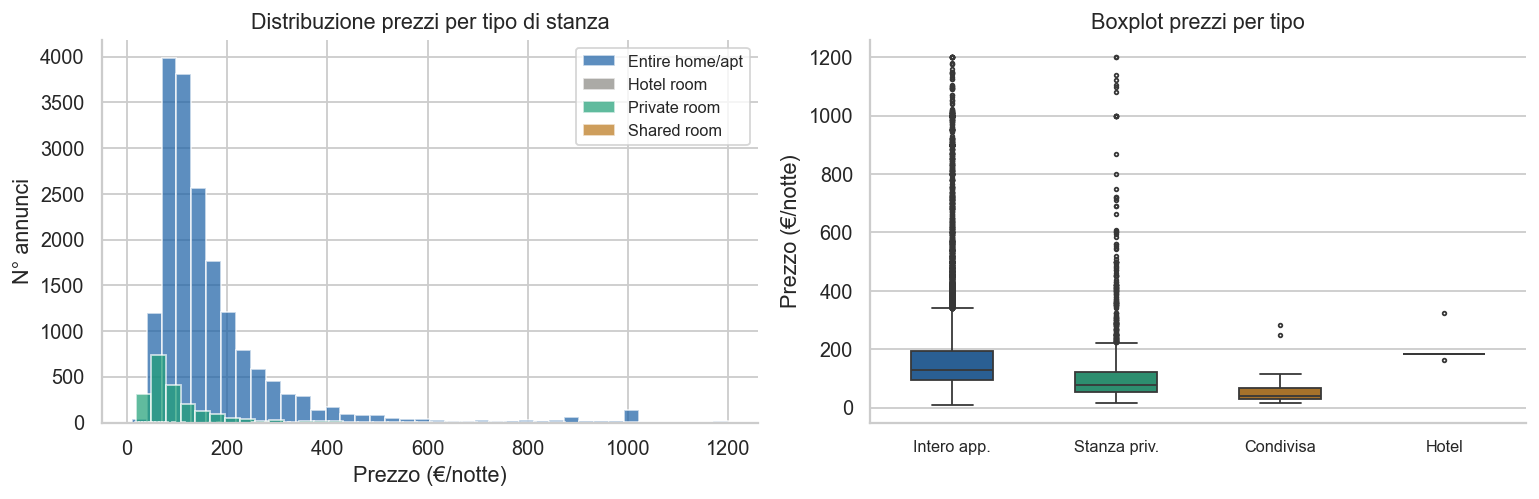

Mediane: {'Entire home/apt': 129.0, 'Hotel room': 183.0, 'Private room': 78.0, 'Shared room': 41.5}


In [53]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Istogramma prezzi per room type
colors = {'Entire home/apt': '#185FA5', 'Private room': '#1D9E75',
          'Shared room': '#BA7517', 'Hotel room': '#888780'}
for rt, grp in df.groupby('room_type'):
    axes[0].hist(grp['price'], bins=40, alpha=0.7, label=rt, color=colors.get(rt, 'gray'))
axes[0].set_title('Distribuzione prezzi per tipo di stanza', fontsize=12)
axes[0].set_xlabel('Prezzo (€/notte)')
axes[0].set_ylabel('N° annunci')
axes[0].legend(fontsize=9)

# Boxplot
order = ['Entire home/apt', 'Private room', 'Shared room', 'Hotel room']
palette = [colors[r] for r in order if r in df['room_type'].unique()]
sns.boxplot(data=df, x='room_type', y='price', order=order,
            palette=palette, ax=axes[1], width=0.5, fliersize=2)
axes[1].set_title('Boxplot prezzi per tipo', fontsize=12)
axes[1].set_xlabel('')
axes[1].set_ylabel('Prezzo (€/notte)')
axes[1].set_xticklabels(['Intero app.', 'Stanza priv.', 'Condivisa', 'Hotel'], fontsize=9)

plt.tight_layout()
plt.savefig('Output/plots/fig1_price_distribution.png', bbox_inches='tight')
plt.show()
print(f"Mediane: {df.groupby('room_type')['price'].median().to_dict()}")

---
## 4. EDA – Analisi per quartiere

In [54]:
neigh = df.groupby('neighbourhood').agg(
    n_listings        = ('id', 'count'),
    median_price      = ('price', 'median'),
    pct_entire        = ('is_entire_home', 'mean'),
    pct_professional  = ('is_professional_host', 'mean'),
    avg_availability  = ('availability_365', 'mean'),
    pct_active        = ('is_active', 'mean'),
).round(3).sort_values('n_listings', ascending=False)

print('Top 20 quartieri per numero di annunci:')
neigh.head(20)

Top 20 quartieri per numero di annunci:


,n_listings,median_price,pct_entire,pct_professional,avg_availability,pct_active
neighbourhood,,,,,,
Buenos Aires - Venezia,1669,141.0,0.893,0.437,201.554,0.766
Duomo,1446,252.0,0.942,0.662,212.447,0.737
Centrale,914,141.0,0.894,0.463,208.278,0.817
Sarpi,907,126.0,0.922,0.470,200.691,0.752
Brera,853,209.0,0.953,0.524,200.875,0.743
Loreto,797,103.0,0.880,0.360,199.642,0.750
Navigli,783,126.0,0.937,0.405,199.664,0.780
Ticinese,742,134.0,0.926,0.429,192.237,0.757
Isola,648,124.5,0.887,0.372,204.304,0.725


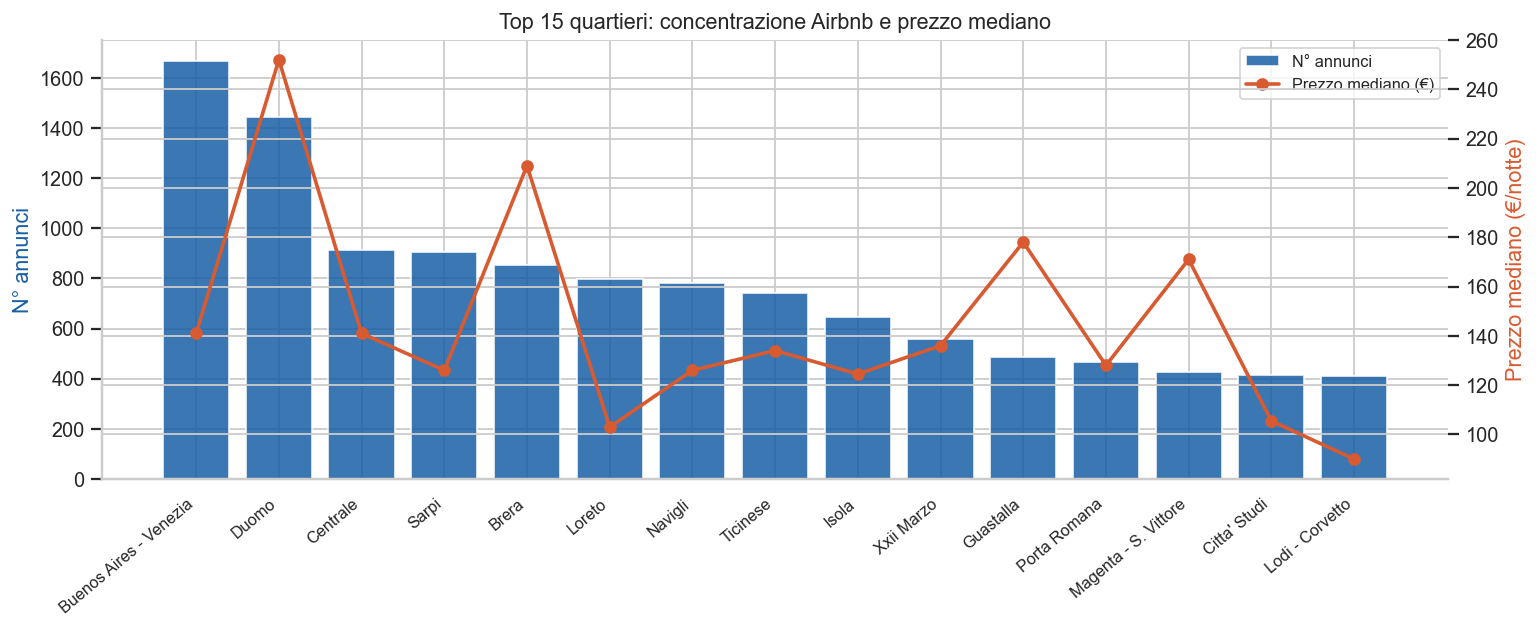

In [55]:
top15 = neigh.head(15).copy()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

x = range(len(top15))
bars = ax1.bar(x, top15['n_listings'], color='#185FA5', alpha=0.85, label='N° annunci')
line, = ax2.plot(x, top15['median_price'], color='#D85A30', marker='o',
                 linewidth=2, markersize=6, label='Prezzo mediano (€)')

ax1.set_xticks(x)
ax1.set_xticklabels(top15.index, rotation=40, ha='right', fontsize=9)
ax1.set_ylabel('N° annunci', color='#185FA5')
ax2.set_ylabel('Prezzo mediano (€/notte)', color='#D85A30')
ax1.set_title('Top 15 quartieri: concentrazione Airbnb e prezzo mediano', fontsize=12)

lines = [bars, line]
labels = ['N° annunci', 'Prezzo mediano (€)']
ax1.legend(lines, labels, loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('Output/plots/fig2_neighbourhood_analysis.png', bbox_inches='tight')
plt.show()

---
## 5. EDA – Struttura degli host

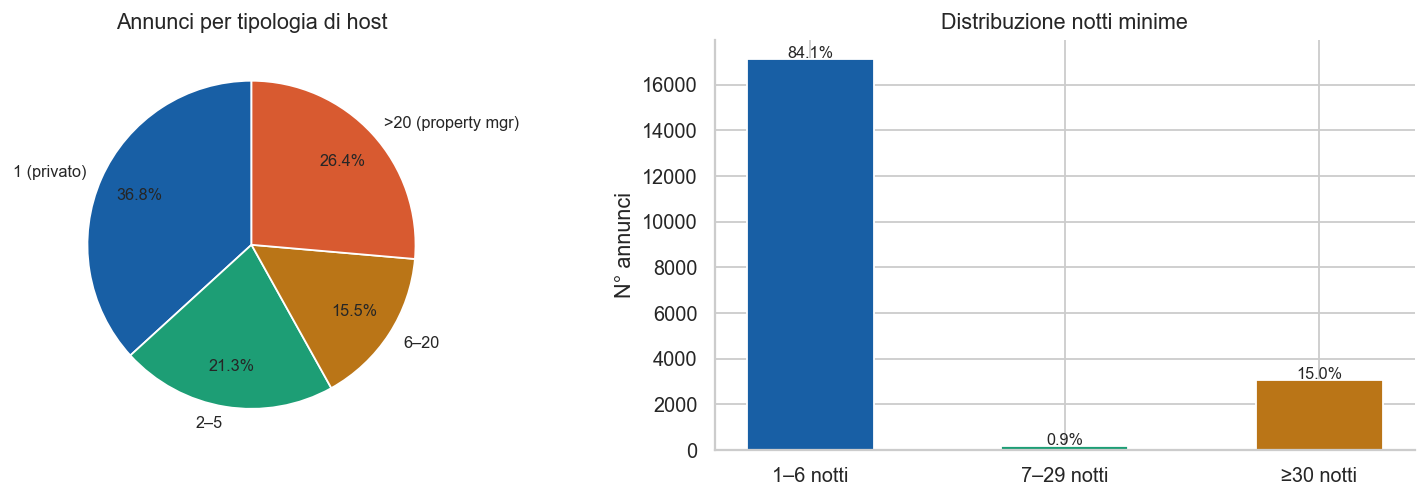

Host professionali (>5 listing): 41.9% degli annunci
Annunci long-term (>=30 gg): 15.0%


In [56]:
def host_tier(n):
    if n == 1:   return '1 (privato)'
    elif n <= 5: return '2–5'
    elif n <= 20:return '6–20'
    else:        return '>20 (property mgr)'

df['host_tier'] = df['calculated_host_listings_count'].apply(host_tier)
tier_order = ['1 (privato)', '2–5', '6–20', '>20 (property mgr)']
tier_counts = df['host_tier'].value_counts().reindex(tier_order)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Torta host tier
colors_tier = ['#185FA5', '#1D9E75', '#BA7517', '#D85A30']
axes[0].pie(tier_counts, labels=tier_order, autopct='%1.1f%%',
            colors=colors_tier, startangle=90,
            textprops={'fontsize': 9}, pctdistance=0.75)
axes[0].set_title('Annunci per tipologia di host', fontsize=12)

# Minimum nights breakdown
def nights_tier(n):
    if n <= 6:   return '1–6 notti'
    elif n <= 29:return '7–29 notti'
    else:        return '≥30 notti'

df['nights_tier'] = df['minimum_nights'].apply(nights_tier)
nights_order = ['1–6 notti', '7–29 notti', '≥30 notti']
nights_counts = df['nights_tier'].value_counts().reindex(nights_order)
colors_nights = ['#185FA5', '#1D9E75', '#BA7517']

axes[1].bar(nights_order, nights_counts, color=colors_nights, width=0.5)
for i, v in enumerate(nights_counts):
    axes[1].text(i, v + 50, f'{v/len(df)*100:.1f}%', ha='center', fontsize=9)
axes[1].set_title('Distribuzione notti minime', fontsize=12)
axes[1].set_ylabel('N° annunci')

plt.tight_layout()
plt.savefig('Output/plots/fig3_host_structure.png', bbox_inches='tight')
plt.show()

print(f"Host professionali (>5 listing): {(df['calculated_host_listings_count']>5).mean()*100:.1f}% degli annunci")
print(f"Annunci long-term (>=30 gg): {df['is_long_term'].mean()*100:.1f}%")

---
## 6. EDA – Licenze e conformità normativa

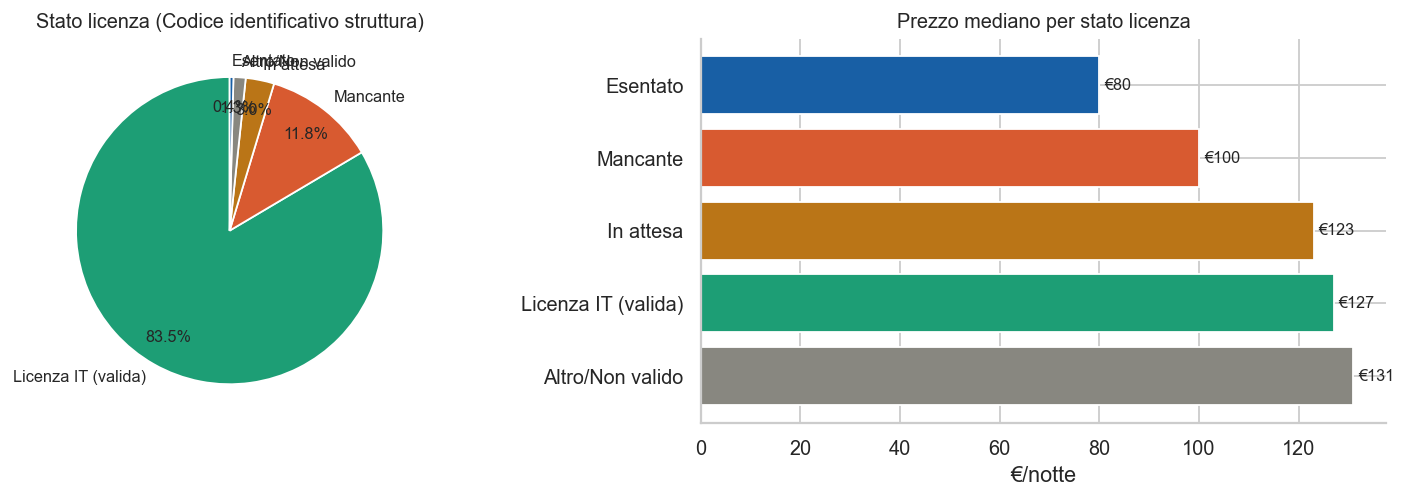

lic_category
Licenza IT (valida)    17001
Mancante                2405
In attesa                610
Altro/Non valido         261
Esentato                  80
Name: count, dtype: int64


In [57]:
total = len(df)
has_lic = df['has_license'].sum()
no_lic  = total - has_lic

# Categorizza le licenze
def lic_category(val):
    if pd.isna(val): return 'Mancante'
    v = str(val).strip()
    if v.upper().startswith('IT015146'): return 'Licenza IT (valida)'
    if 'exempt' in v.lower(): return 'Esentato'
    if 'applied' in v.lower(): return 'In attesa'
    return 'Altro/Non valido'

df['lic_category'] = df['license'].apply(lic_category)
lic_counts = df['lic_category'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors_lic = {'Licenza IT (valida)': '#1D9E75', 'Mancante': '#D85A30',
              'In attesa': '#BA7517', 'Esentato': '#185FA5', 'Altro/Non valido': '#888780'}
c_list = [colors_lic.get(k, 'gray') for k in lic_counts.index]

axes[0].pie(lic_counts, labels=lic_counts.index, autopct='%1.1f%%',
            colors=c_list, startangle=90, textprops={'fontsize': 9}, pctdistance=0.8)
axes[0].set_title('Stato licenza (Codice identificativo struttura)', fontsize=11)

# Prezzo medio per stato licenza
price_by_lic = df.groupby('lic_category')['price'].median().sort_values(ascending=False)
axes[1].barh(price_by_lic.index, price_by_lic.values,
             color=[colors_lic.get(k, 'gray') for k in price_by_lic.index])
axes[1].set_title('Prezzo mediano per stato licenza', fontsize=11)
axes[1].set_xlabel('€/notte')
for i, v in enumerate(price_by_lic.values):
    axes[1].text(v + 1, i, f'€{v:.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('Output/plots/fig4_license_analysis.png', bbox_inches='tight')
plt.show()

print(lic_counts)

---
## 7. EDA – Disponibilità e attività

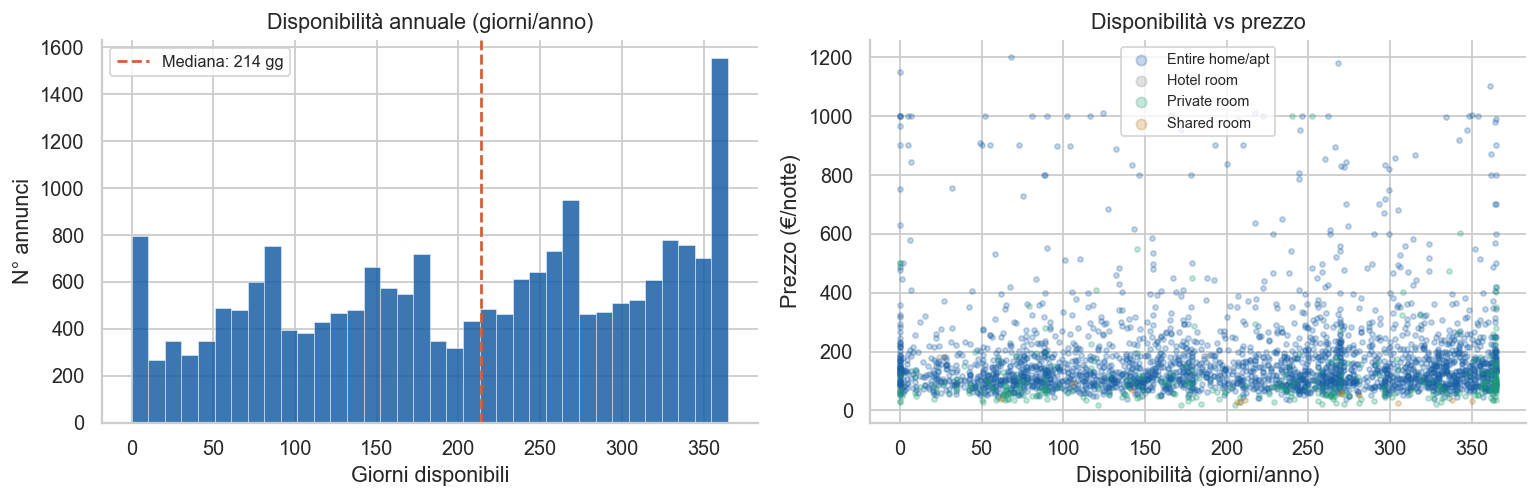

Annunci con availability=0 (inattivi/bloccati): 462
Annunci con alta disponibilità (>270 gg/anno): 6497 (31.9%)


In [58]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribuzione availability_365
axes[0].hist(df['availability_365'], bins=36, color='#185FA5', alpha=0.85, edgecolor='white', linewidth=0.3)
axes[0].axvline(df['availability_365'].median(), color='#D85A30', linewidth=1.5,
                linestyle='--', label=f"Mediana: {df['availability_365'].median():.0f} gg")
axes[0].set_title('Disponibilità annuale (giorni/anno)', fontsize=12)
axes[0].set_xlabel('Giorni disponibili')
axes[0].set_ylabel('N° annunci')
axes[0].legend(fontsize=9)

# Scatter: disponibilità vs prezzo (sample 3000)
sample = df.sample(min(3000, len(df)), random_state=42)
color_map = {'Entire home/apt': '#185FA5', 'Private room': '#1D9E75',
             'Shared room': '#BA7517', 'Hotel room': '#888780'}
for rt, grp in sample.groupby('room_type'):
    axes[1].scatter(grp['availability_365'], grp['price'], alpha=0.25, s=8,
                    color=color_map.get(rt, 'gray'), label=rt)
axes[1].set_title('Disponibilità vs prezzo', fontsize=12)
axes[1].set_xlabel('Disponibilità (giorni/anno)')
axes[1].set_ylabel('Prezzo (€/notte)')
axes[1].legend(fontsize=8, markerscale=2)

plt.tight_layout()
plt.savefig('Output/plots/fig5_availability.png', bbox_inches='tight')
plt.show()

print(f"Annunci con availability=0 (inattivi/bloccati): {(df['availability_365']==0).sum()}")
print(f"Annunci con alta disponibilità (>270 gg/anno): {(df['availability_365']>270).sum()} ({(df['availability_365']>270).mean()*100:.1f}%)")

---
## 8. Correlazione tra variabili numeriche

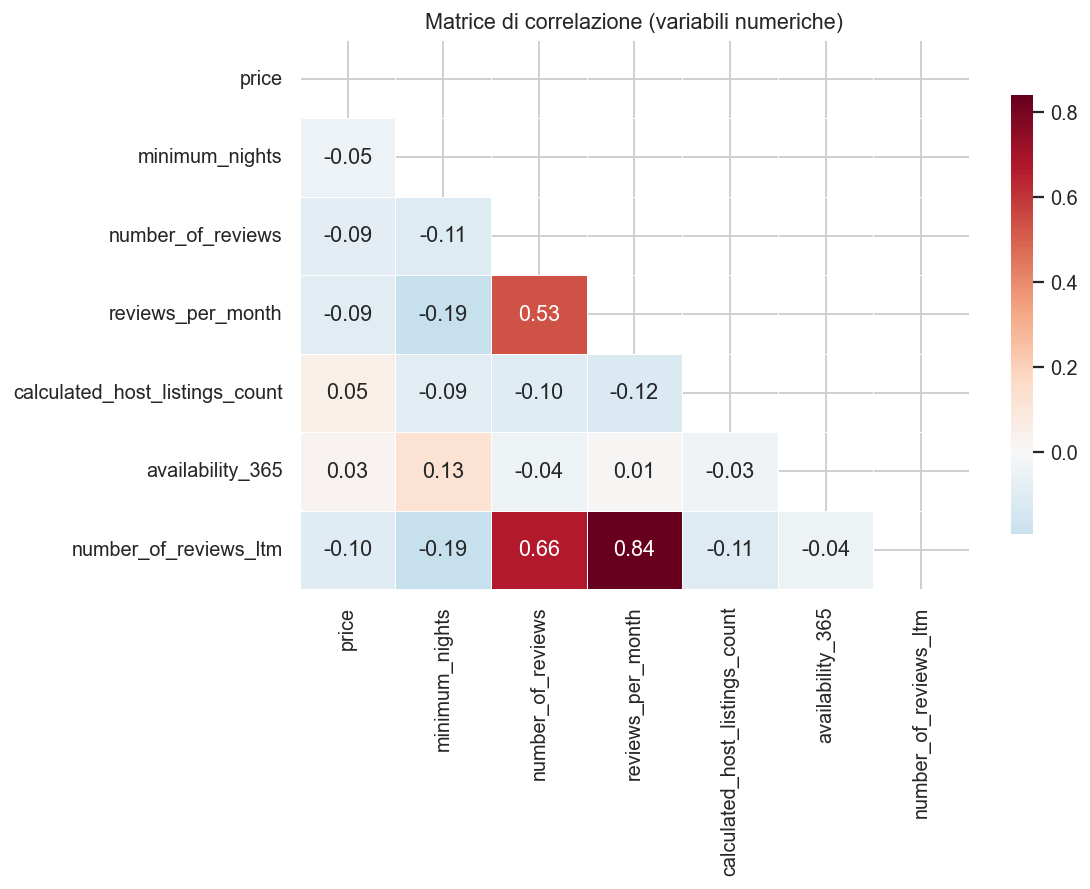

In [59]:
num_cols = ['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month',
            'calculated_host_listings_count', 'availability_365', 'number_of_reviews_ltm']

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Matrice di correlazione (variabili numeriche)', fontsize=12)
plt.tight_layout()
plt.savefig('Output/plots/fig6_correlation_matrix.png', bbox_inches='tight')
plt.show()

---
## 9. Metriche chiave per il collegamento con i dati OMI

Esportiamo il dataset pulito e il summary per quartiere, che servirà per la join con le quotazioni OMI.

In [60]:
# Airbnb pressure metric per quartiere:
# rapporto tra annunci di interi appartamenti e numero totale di annunci del quartiere
neigh_export = df.groupby('neighbourhood').agg(
    n_listings            = ('id', 'count'),
    n_entire_home         = ('is_entire_home', 'sum'),
    pct_entire            = ('is_entire_home', 'mean'),
    median_price          = ('price', 'median'),
    mean_price            = ('price', 'mean'),
    pct_professional_host = ('is_professional_host', 'mean'),
    pct_long_term         = ('is_long_term', 'mean'),
    avg_availability      = ('availability_365', 'mean'),
    pct_active            = ('is_active', 'mean'),
    pct_licensed          = ('has_license', 'mean'),
    lat_mean              = ('latitude', 'mean'),
    lon_mean              = ('longitude', 'mean'),
).round(3).reset_index()

# «Airbnb pressure» = n° interi appartamenti (sottratti al mercato)
neigh_export['airbnb_pressure'] = neigh_export['n_entire_home']

DATA_DIR = r'C:\Users\matil\OneDrive\Desktop\LUISS\data visualization\Data-Visualization-2026\Data'
neigh_export.to_csv(f'{DATA_DIR}\\neighbourhood_summary.csv', index=False)
df.to_csv(f'{DATA_DIR}\\listings_milan_clean.csv', index=False)

print('File esportati:')
print('  - listings_milan_clean.csv    (dataset pulito con colonne derivate)')
print('  - neighbourhood_summary.csv   (aggregato per quartiere, pronto per join OMI)')
print(f'\nQuartieri totali: {len(neigh_export)}')
print(f'Record nel dataset pulito: {len(df)}')

neigh_export.sort_values('n_listings', ascending=False).head(10)

File esportati:
  - listings_milan_clean.csv    (dataset pulito con colonne derivate)
  - neighbourhood_summary.csv   (aggregato per quartiere, pronto per join OMI)

Quartieri totali: 87
Record nel dataset pulito: 20357


,neighbourhood,n_listings,n_entire_home,pct_entire,median_price,mean_price,pct_professional_host,pct_long_term,avg_availability,pct_active,pct_licensed,lat_mean,lon_mean,airbnb_pressure
10,Buenos Aires - Venezia,1669,1490,0.893,141.0,174.890,0.437,0.121,201.554,0.766,0.907,45.478,9.212,1490
19,Duomo,1446,1362,0.942,252.0,299.568,0.662,0.098,212.447,0.737,0.943,45.463,9.187,1362
12,Centrale,914,817,0.894,141.0,174.200,0.463,0.078,208.278,0.817,0.950,45.486,9.205,817
70,Sarpi,907,836,0.922,126.0,164.854,0.470,0.133,200.691,0.752,0.900,45.482,9.172,836
8,Brera,853,813,0.953,209.0,255.835,0.524,0.140,200.875,0.743,0.898,45.475,9.187,813
36,Loreto,797,701,0.880,103.0,146.856,0.360,0.132,199.642,0.750,0.903,45.491,9.220,701
42,Navigli,783,734,0.937,126.0,158.280,0.405,0.158,199.664,0.780,0.886,45.450,9.171,734
76,Ticinese,742,687,0.926,134.0,172.646,0.429,0.139,192.237,0.757,0.899,45.452,9.180,687
32,Isola,648,575,0.887,124.5,159.954,0.372,0.150,204.304,0.725,0.867,45.490,9.189,575
86,Xxii Marzo,558,514,0.921,136.0,176.520,0.437,0.156,210.054,0.726,0.878,45.462,9.212,514


---
## 10. Riepilogo decisioni di pulizia

| Operazione | Righe/colonne coinvolte | Motivazione |
|---|---|---|
| Drop `neighbourhood_group` | 1 colonna | 100% NaN, nessun valore informativo |
| Drop righe senza `price` | 2.395 righe | Non utilizzabili per analisi economica |
| Rimozione outlier prezzo > €1.200 (99° pct) | 196 righe | Distorcono media e visualizzazioni |
| Cap `minimum_nights` a 365 | valori > 365 | Max sensato per un'analisi STR |
| Normalizzazione `neighbourhood` | case + strip | Uniformità per join e aggregazioni |
| Normalizzazione `license` | strip | Rimozione spazi extra |
| Aggiunta colonne derivate | 5 colonne | `is_entire_home`, `is_professional_host`, `is_long_term`, `is_active`, `has_license` |

**Dataset finale**: 20.357 righe × 22 colonne  
**Prossimo step**: join con quotazioni OMI per zona catastale → analisi correlazione densità Airbnb / prezzi locazione